In [1]:
import tensorflow as tf
print(tf.__version__)

2.0.0


## Data Pipeline for Deep Learning

 ### Coding tutorials
 1. [Keras datasets](#coding_tutorial_1)
 2. [ Dataset generators](#coding_tutorial_2)
 3. [ Keras image data augmentation](#coding_tutorial_3)
 4. [ The Dataset class](#coding_tutorial_4)
 5. [ Training with Datasets](#coding_tutorial_5)

***

<a name="coding_tutorial_1"></a>
### Keras datasets

For a list of Keras datasets and documentation on recommended usage, see [this link](https://keras.io/datasets/).

In [64]:
import numpy as np
import matplotlib.pyplot as plt

#### Load the CIFAR-100 Dataset

In [19]:
from tensorflow.keras.datasets import cifar100

In [20]:
# Load the CIFAR-100 dataset

(train_images, train_labels), (test_images, test_labels) = cifar100.load_data()

In [21]:
# Confirm that reloading the dataset does not require a download

(train_images, train_labels), (test_images, test_labels) = cifar100.load_data()

#### Examine the Dataset

In [22]:
# Examine the shape of the data.

print("train images shape", train_images.shape)
print("train labels shape", train_labels.shape)

train images shape (50000, 32, 32, 3)
train labels shape (50000, 1)


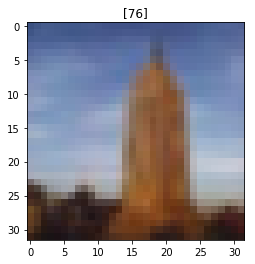

In [23]:
# Examine one of the images and its corresponding label

plt.imshow(train_images[45])
plt.title(train_labels[45])
plt.show()

In [24]:
# Load the list of labels from a JSON file
import json

with open('data/cifar100_fine_labels.json', 'r') as fine_labels:
    cifar100_fine_labels = json.load(fine_labels)

The list of labels for the CIFAR-100 dataset are available [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In [25]:
# Print a few of the labels

cifar100_fine_labels[:10]

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle']

In [26]:
# Print the corresponding label for the example above

cifar100_fine_labels[76]

'skyscraper'

#### Load the data using different label modes

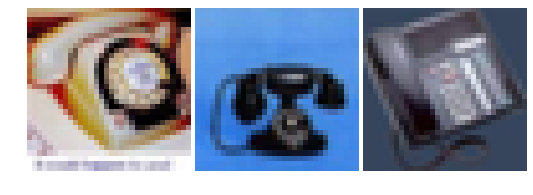

In [27]:
# Display a few examples from category 87 (index 86) and the list of labels

examples = train_images[(train_labels.T == 86)[0]][:3]
fig, ax = plt.subplots(1, 3, figsize=[9, 3])
plt.subplots_adjust(wspace=0.01)

ax[0].imshow(examples[0])
ax[1].imshow(examples[1])
ax[2].imshow(examples[2])

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

In [28]:
# Reload the data using the 'coarse' label mode

(train_images, train_labels), (test_images, test_labels) = cifar100.load_data(label_mode='coarse')

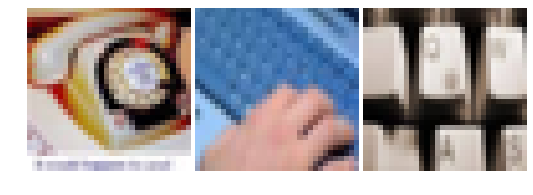

In [29]:
# Display three images from the dataset with the label 6 (index 5)

examples = train_images[(train_labels.T == 5)[0]][:3]
fig, ax = plt.subplots(1, 3, figsize=[9, 3])
plt.subplots_adjust(wspace=0.01)

ax[0].imshow(examples[0])
ax[1].imshow(examples[1])
ax[2].imshow(examples[2])

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

In [30]:
# Load the list of coarse labels from a JSON file

with open('data/cifar100_coarse_labels.json', 'r') as coarse_labels:
    cifar100_coarse_labels = json.load(coarse_labels)

In [33]:
# Print a few of the labels

cifar100_coarse_labels[:10]

['aquatic mammals',
 'fish',
 'flowers',
 'food containers',
 'fruit and vegetables',
 'household electrical device',
 'household furniture',
 'insects',
 'large carnivores',
 'large man-made outdoor things']

In [35]:
# Print the corresponding label for the example above

cifar100_coarse_labels[19]

'vehicles 2'

#### Load the IMDB Dataset

In [137]:
from tensorflow.keras.datasets import imdb

In [138]:
# Load the IMDB dataset

(train_seqs, train_labels), (test_seqs, test_labels) = imdb.load_data()

In [139]:
# Print an example from the training dataset, along with its corresponding label

print("Train imdb data\n", train_seqs[55])
print("Train imdb label\n", train_labels[55])

Train imdb data
 [1, 5011, 892, 711, 12, 2774, 38, 2428, 145, 11, 4, 3673, 7, 4292, 13, 377, 95, 4, 20, 385, 46, 5, 4, 5011, 17679, 28, 77, 10033, 19, 4, 711, 17679, 126, 237, 10, 10, 4, 711, 17679, 135, 3006, 5011, 562, 6, 87, 189, 787, 5, 2262, 12, 4, 5011, 17679, 92, 202, 6, 1543, 44, 4669, 65, 36, 740, 44, 43886, 5430, 665, 370, 2445, 14, 9, 6, 22, 36, 6807, 12, 144, 30, 1192, 23, 94, 205, 17, 12, 571, 199, 9686, 26, 2296, 472, 10, 10, 48, 31, 2692, 12, 2855, 17, 35, 1253, 7, 4669, 667, 4, 3537, 9, 849, 6, 2104, 6, 1053, 1434, 6, 201, 7, 10032, 1321, 58210, 10, 10, 13, 343, 8, 1821, 15, 23, 7392, 2979, 4, 564, 4289, 2820, 2133, 7, 3458, 1349, 71689, 3458, 4313, 525, 47, 6, 2577, 17, 35, 7858, 7, 1031, 7131, 279, 59, 16, 2218, 18, 41, 1302, 4400, 7, 30928, 4249, 42, 223, 6891, 21, 4, 117, 1336, 7621, 513, 7, 50737, 16308, 152, 1778, 23, 101, 4911, 11, 41, 45618, 2518, 10, 10, 5011, 4, 42675, 242, 258, 41, 46293, 190, 29, 7, 265, 9, 4, 147, 8839, 5, 1192, 23, 94, 205, 5068, 27, 881, 

In [140]:
# Get the lengths of the input sequences

sequence_lengths = [len(seq) for seq in train_seqs]

In [141]:
# Determine the maximum and minimum sequence length

max_seq = max(sequence_lengths)
min_seq = min(sequence_lengths)

print('Maximum length of a sequence = ', max_seq)
print('Minimum length of a sequence = ', min_seq)

Maximum length of a sequence =  2494
Minimum length of a sequence =  11


#### Using Keyword Arguments

In [142]:
# Load the data ignoring the 50 most frequent words, use oov_char=2 (this is the default)

(imdb_train_data, imdb_train_label), (imdb_test_data, imdb_test_labels) = imdb.load_data(oov_char=2,
                                                                                         skip_top=50
                                                                                        )

In [143]:
# Get the lengths of the input sequences

sequence_lengths_n = [len(seq) for seq in imdb_train_data]

In [144]:
# Determine the maximum and minimum sequence length

max_seq_n = max(sequence_lengths_n)
min_seq_n = min(sequence_lengths_n)

print('Maximum length of a sequence after removing 50 top words = ', max_seq_n)
print('Minimum length of a sequence after removing 50 top words = ', min_seq_n)

Maximum length of a sequence after removing 50 top words =  2494
Minimum length of a sequence after removing 50 top words =  11


In [145]:
# Define functions for filtering the sequences

def remove_oov_char(element):
    ''' Filter function for removing the oov_char. '''
    return [word for word in element if word != 2]

def filter_list(lst):
    ''' Run remove_oov_char on elements in a list. '''
    return [remove_oov_char(element) for element in lst]

In [146]:
# Remove the oov_char from the sequences using the filter_list function

truncated_seqs = filter_list(imdb_train_data)

In [147]:
# Get the lengths of the input sequences

sequence_lengths_truncated = [len(seq) for seq in imdb_train_data]

In [148]:
# Determine the maximum and minimum sequence length

max_seq_trunc = max(sequence_lengths_truncated)
min_seq_trunc = min(sequence_lengths_truncated)

print('Maximum length of a sequence after truncation = ', max_seq_trunc)
print('Minimum length of a sequence after truncation = ', min_seq_trunc)

Maximum length of a sequence after truncation =  2494
Minimum length of a sequence after truncation =  11


***
<a name="coding_tutorial_2"></a>
## Dataset generators

In [149]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Load the UCI Fertility Dataset

We will be using a dataset available at https://archive.ics.uci.edu/ml/datasets/Fertility from UC Irvine.

In [150]:
# Load the fertility dataset

headers = ['Season', 'Age', 'Diseases', 'Trauma', 'Surgery', 'Fever', 'Alcohol', 'Smoking', 'Sitting', 'Output']
fertility = pd.read_csv('data/fertility_diagnosis.txt', delimiter=',', header=None, names=headers)

In [151]:
# Print the shape of the DataFrame

fertility.shape

(100, 10)

In [152]:
# Show the head of the DataFrame

fertility.head()

,Season,Age,Diseases,Trauma,Surgery,Fever,Alcohol,Smoking,Sitting,Output
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,N
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,O
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,N
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,N
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,O


#### Process the data

In [153]:
# Map the 'Output' feature from 'N' to 0 and from 'O' to 1

fertility['Output'] = fertility['Output'].map(lambda x: 0.0 if x == 'N' else 1.0)

In [154]:
# Show the head of the DataFrame

fertility.head()

,Season,Age,Diseases,Trauma,Surgery,Fever,Alcohol,Smoking,Sitting,Output
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,0.0
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,1.0
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,0.0
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,0.0
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,1.0


In [155]:
# Convert the DataFrame so that the features are mapped to floats

fertility = fertility.astype('float32')

In [156]:
# Shuffle the DataFrame

fertility = fertility.sample(frac=1).reset_index(drop=True)

In [157]:
# Show the head of the DataFrame

fertility.head()

,Season,Age,Diseases,Trauma,Surgery,Fever,Alcohol,Smoking,Sitting,Output
0,-0.33,0.53,1.0,1.0,0.0,0.0,0.8,0.0,0.75,0.0
1,1.00,0.58,0.0,0.0,0.0,1.0,0.8,1.0,0.44,0.0
2,-1.00,0.72,1.0,1.0,1.0,1.0,0.8,-1.0,0.19,0.0
3,1.00,0.67,1.0,0.0,0.0,0.0,1.0,-1.0,0.25,0.0
4,-0.33,0.81,1.0,1.0,1.0,0.0,1.0,1.0,0.38,0.0


In [158]:
# Convert the field Season to a one-hot encoded vector

fertility = pd.get_dummies(fertility, prefix='Season', columns=['Season'])

In [159]:
# Show the head of the DataFrame

fertility.head()

,Age,Diseases,Trauma,Surgery,Fever,Alcohol,Smoking,Sitting,Output,Season_-1.0,Season_-0.33000001311302185,Season_0.33000001311302185,Season_1.0
0,0.53,1.0,1.0,0.0,0.0,0.8,0.0,0.75,0.0,0,1,0,0
1,0.58,0.0,0.0,0.0,1.0,0.8,1.0,0.44,0.0,0,0,0,1
2,0.72,1.0,1.0,1.0,1.0,0.8,-1.0,0.19,0.0,1,0,0,0
3,0.67,1.0,0.0,0.0,0.0,1.0,-1.0,0.25,0.0,0,0,0,1
4,0.81,1.0,1.0,1.0,0.0,1.0,1.0,0.38,0.0,0,1,0,0


*N.B. The below cell has been updated since the coding tutorial.*

In [160]:
# Move the Output column such that it is the last column in the DataFrame

fertility = fertility.reindex(columns=[col for col in fertility.columns if col != 'Output'] + ['Output'])

In [161]:
# Show the head of the DataFrame

fertility.head()

,Age,Diseases,Trauma,Surgery,Fever,Alcohol,Smoking,Sitting,Season_-1.0,Season_-0.33000001311302185,Season_0.33000001311302185,Season_1.0,Output
0,0.53,1.0,1.0,0.0,0.0,0.8,0.0,0.75,0,1,0,0,0.0
1,0.58,0.0,0.0,0.0,1.0,0.8,1.0,0.44,0,0,0,1,0.0
2,0.72,1.0,1.0,1.0,1.0,0.8,-1.0,0.19,1,0,0,0,0.0
3,0.67,1.0,0.0,0.0,0.0,1.0,-1.0,0.25,0,0,0,1,0.0
4,0.81,1.0,1.0,1.0,0.0,1.0,1.0,0.38,0,1,0,0,0.0


In [162]:
# Convert the DataFrame to a numpy array.

fertility = fertility.to_numpy()

#### Split the Data

In [163]:
# Split the dataset into training and validation set

training = fertility[0:70]
validation = fertility[70:100]

In [164]:
# Verify the shape of the training data

training.shape

(70, 13)

In [165]:
# Separate the features and labels for the validation and training data

training_features = training[:, 0:-1]
training_labels = training[:, -1]
validation_features = validation[:, 0:-1]
validation_labels = validation[:, -1]

#### Create the Generator

In [166]:
# Create a function that returns a generator producing inputs and labels

def get_generator(features, labels, batch_size=1):
    for n in range(int(len(features) / batch_size)):
        yield (features[n*batch_size: (n+1)*batch_size], labels[n*batch_size: (n+1)*batch_size])

In [167]:
# Apply the function to our training features and labels with a batch size of 10

train_generator = get_generator(training_features, training_labels, batch_size=10)

In [168]:
# Test the generator using the next() function

next(train_generator)

(array([[ 0.53,  1.  ,  1.  ,  0.  ,  0.  ,  0.8 ,  0.  ,  0.75,  0.  ,
          1.  ,  0.  ,  0.  ],
        [ 0.58,  0.  ,  0.  ,  0.  ,  1.  ,  0.8 ,  1.  ,  0.44,  0.  ,
          0.  ,  0.  ,  1.  ],
        [ 0.72,  1.  ,  1.  ,  1.  ,  1.  ,  0.8 , -1.  ,  0.19,  1.  ,
          0.  ,  0.  ,  0.  ],
        [ 0.67,  1.  ,  0.  ,  0.  ,  0.  ,  1.  , -1.  ,  0.25,  0.  ,
          0.  ,  0.  ,  1.  ],
        [ 0.81,  1.  ,  1.  ,  1.  ,  0.  ,  1.  ,  1.  ,  0.38,  0.  ,
          1.  ,  0.  ,  0.  ],
        [ 0.92,  1.  ,  0.  ,  0.  ,  1.  ,  0.6 , -1.  ,  0.19,  0.  ,
          1.  ,  0.  ,  0.  ],
        [ 0.78,  1.  ,  1.  ,  1.  ,  0.  ,  0.6 ,  0.  ,  0.13,  0.  ,
          0.  ,  0.  ,  1.  ],
        [ 0.64,  1.  ,  1.  ,  1.  ,  0.  ,  0.8 , -1.  ,  0.31,  0.  ,
          1.  ,  0.  ,  0.  ],
        [ 0.78,  1.  ,  0.  ,  1.  ,  1.  ,  1.  ,  1.  ,  0.25,  1.  ,
          0.  ,  0.  ,  0.  ],
        [ 0.75,  1.  ,  1.  ,  1.  ,  0.  ,  1.  ,  1.  ,  0.25,  0.  ,
 

#### Build the model

In [36]:
# Create a model using Keras with 3 layers

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, BatchNormalization

input_shape = (12,)
output_shape = (1,)

model_input = Input(input_shape)
batch_1 = BatchNormalization(momentum=0.8)(model_input)
dense_1 = Dense(100, activation='relu')(batch_1)
batch_2 = BatchNormalization(momentum=0.8)(dense_1)
output = Dense(1, activation='sigmoid')(batch_2)

model = Model(model_input, output)

In [170]:
# Display the model summary to show the resultant structure

model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 12)]              0         
_________________________________________________________________
batch_normalization_4 (Batch (None, 12)                48        
_________________________________________________________________
dense_4 (Dense)              (None, 100)               1300      
_________________________________________________________________
batch_normalization_5 (Batch (None, 100)               400       
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 101       
Total params: 1,849
Trainable params: 1,625
Non-trainable params: 224
_________________________________________________________________


#### Compile the model

In [171]:
# Create the optimizer object

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)

In [172]:
# Compile the model with loss function and metric

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

#### Train and evaluate the model using the generator

In [173]:
# Calculate the number of training steps per epoch for the given batch size.

batch_size = 5
train_steps = len(training) // batch_size

In [174]:
# Set the epochs to 3

epochs = 3

In [175]:
# Train the model
for epoch in range(epochs):
    train_generator = get_generator(training_features, training_labels, batch_size=batch_size)
    validation_generator = get_generator(validation_features, validation_labels, batch_size=batch_size)
    model.fit_generator(train_generator, steps_per_epoch=train_steps, 
                        validation_data=(validation_generator),
                        validation_steps=1)

14/14 [==============================] - 1s 37ms/step - loss: 0.1095 - accuracy: 0.9857 - val_loss: 0.3940 - val_accuracy: 0.8000


In [176]:
# Try to run the fit_generator function once more; observe what happens

model.fit_generator(train_generator, steps_per_epoch=train_steps)

ValueError: Empty training data.

#### Make an infinitely looping generator

In [199]:
# Create a function that returns an infinitely looping generator
def get_generator_cyclic(features, labels, batch_size):
    while True:
        for row in range(len(features) // batch_size):
            row_features = features[row*batch_size : (row+1)*batch_size]
            row_labels = labels[row*batch_size : (row+1)*batch_size]
            yield (row_features, row_labels)

        permutated_idxs = np.random.permutation(len(features))
        features = features[permutated_idxs]
        labels = labels[permutated_idxs]
            

In [205]:
# Create a generator using this function.

train_generator_cyclic = get_generator_cyclic(training_features, training_labels, batch_size=batch_size)

In [206]:
# Assert that the new cyclic generator does not raise a StopIteration

for i in range(2*train_steps):
    next(train_generator_cyclic)

In [207]:
# Generate a cyclic validation generator

validation_generator_cyclic = get_generator_cyclic(validation_features, validation_labels, batch_size=batch_size)

In [208]:
# Train the model

model.fit_generator(train_generator_cyclic, steps_per_epoch=train_steps,
                    validation_data=(validation_generator_cyclic),
                    validation_steps=1, epochs=epochs)

Epoch 1/3
14/14 [==============================] - 1s 38ms/step - loss: 0.3363 - accuracy: 0.8286 - val_loss: 0.5666 - val_accuracy: 0.8000
Epoch 2/3
14/14 [==============================] - 1s 37ms/step - loss: 0.2321 - accuracy: 0.9000 - val_loss: 2.0767 - val_accuracy: 0.6000
Epoch 3/3
14/14 [==============================] - 0s 35ms/step - loss: 0.2931 - accuracy: 0.8857 - val_loss: 1.3186 - val_accuracy: 0.6000


#### Evaluate the model and get predictions

In [211]:
# Let's obtain a validation data generator.

validation_generator = get_generator(validation_features, validation_labels, batch_size=30)

In [212]:
# Get predictions on the validation data

validation_predicts = model.predict_generator(validation_generator, steps=1)
validation_predicts = validation_predicts.T[0].round()
print(validation_predicts)

[0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0.]


In [213]:
# Print the corresponding validation labels

print(validation_labels)

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [217]:
# Obtain a validation data generator

validation_generator = get_generator(validation_features, validation_labels, batch_size=30)

In [218]:
# Evaluate the model

loss, acc = model.evaluate(validation_generator, verbose=0)
print('loss =', loss)
print('accuracy =', acc)

loss =  0.5227184891700745
accuracy =  0.8333333


***
<a id="coding_tutorial_3"></a>
## Keras image data augmentation

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#### Load the CIFAR-10 Dataset

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
# Load the CIFAR-10 dataset

(training_features, training_labels), (test_features, test_labels) = cifar10.load_data()

170500096/170498071 [==============================] - 74s 0us/step


In [7]:
# Convert the labels to a one-hot encoding

num_classes = 10

training_labels = tf.keras.utils.to_categorical(training_labels, num_classes)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes)

#### Create a generator function

In [8]:
# Create a function that returns a data generator

def get_generator(features, labels, batch_size=1):
    for n in range(int(len(features) / batch_size)):
        yield (features[n*batch_size : (n+1)*batch_size], labels[n*batch_size : (n+1)*batch_size])

In [9]:
# Use the function we created to get a training data generator with a batch size of 1

training_generator = get_generator(training_features, training_labels)

In [10]:
# Assess the shape of the items generated by training_generator using the `next` function to yield an item.

image, label = next(training_generator)
print(image.shape)
print(label.shape)

(1, 32, 32, 3)
(1, 10)


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


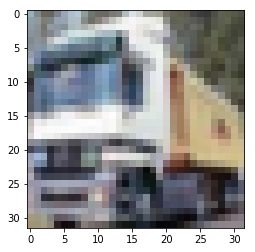

In [11]:
# Test the training generator by obtaining an image using the `next` generator function, and then using imshow to plot it.
# Print the corresponding label

from matplotlib.pyplot import imshow

image, label = next(training_generator)
image_unbatched = image[0,:,:,:]
imshow(image_unbatched)
print(label)

In [12]:
# Reset the generator by re-running the `get_generator` function.

train_generator = get_generator(training_features, training_labels)

#### Create a data augmention generator

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
# Create a function to convert an image to monochrome

def monochrome(x):
    def func_bw(a):
        average_colour = np.mean(a)
        return [average_colour, average_colour, average_colour]
    x = np.apply_along_axis(func_bw, -1, x)
    return x

In [16]:
# Create an ImageDataGenerator object

imagedata_generator = ImageDataGenerator(
    preprocessing_function=monochrome,
    rescale=1/255.,
    rotation_range=180
)

# fit
imagedata_generator.fit(training_features)

Check [the documentation](https://keras.io/preprocessing/image/) for the full list of image data augmentation options. 

In [19]:
# Create an iterable generator using the `flow` function

image_generator_iterable = imagedata_generator.flow(
    training_features,
    training_labels,
    batch_size=1,
    shuffle=False
)

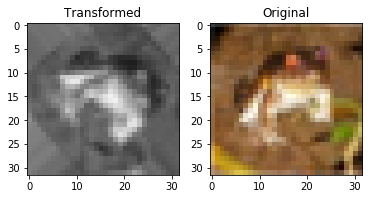

In [20]:
# Show a sample from the generator and compare with the original

image, label = next(image_generator_iterable)
image_orig, label_orig = next(train_generator)
figs, axes = plt.subplots(1, 2)
axes[0].imshow(image[0,:,:,:])
axes[0].set_title('Transformed')
axes[1].imshow(image_orig[0,:,:,:])
axes[1].set_title('Original')
plt.show()

#### Flow from directory

In [21]:
# Inspect the directory structure

train_path = 'data/flowers-recognition-split/train'
val_path = 'data/flowers-recognition-split/val'

In [118]:
# Create an ImageDataGenerator object

datagenerator = ImageDataGenerator(rescale=(1/255.0))

In [119]:
classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [139]:
# Create a training data generator

train_generator = datagenerator.flow_from_directory(
    train_path,
    classes=classes,
    batch_size=64,
    target_size=(16, 16)
)

Found 3027 images belonging to 5 classes.


In [140]:
# Create a validation data generator

validation_generator = datagenerator.flow_from_directory(
    val_path,
    classes=classes,
    batch_size=64,
    target_size=(16, 16)
)

Found 1296 images belonging to 5 classes.


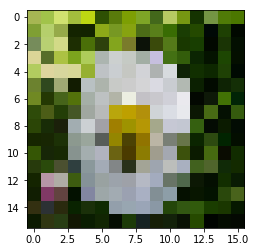

[1. 0. 0. 0. 0.]


In [142]:
# Get and display an image and label from the training generator

x = next(train_generator)

plt.imshow(x[0][4])
plt.show()

print(x[1][4])

In [143]:
# Reset the training generator

train_generator = datagenerator.flow_from_directory(
    train_path,
    classes=classes,
    batch_size=64,
    target_size=(16, 16)
)

Found 3027 images belonging to 5 classes.


#### Create a model to train

In [144]:
# Build a CNN model

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense

model = tf.keras.Sequential()
model.add(Input((16, 16, 3)))
model.add(Conv2D(8, (8, 8), padding='same', activation='relu'))
model.add(MaxPooling2D((4, 4)))
model.add(Conv2D(8, (8, 8), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(4, (4, 4), padding='same', activation='relu'))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(5, activation='softmax'))

In [145]:
# Create an optimizer object

optimizer = tf.keras.optimizers.Adam(1e-3)

In [146]:
# Compile the model

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [147]:
# Print the model summary

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 16, 16, 8)         1544      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 4, 4, 8)           0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 4, 4, 8)           4104      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 2, 2, 8)           0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 2, 2, 4)           516       
_________________________________________________________________
flatten (Flatten)            (None, 16)                0         
_________________________________________________________________
dense (Dense)                (None, 16)                2

#### Train the model

In [149]:
# Calculate the training generator and test generator steps per epoch

train_steps_per_epoch = train_generator.n // train_generator.batch_size
val_steps = validation_generator.n // validation_generator.batch_size
print(train_steps_per_epoch, val_steps)

47 20


In [151]:
# Fit the model

model.fit_generator(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=val_steps,
    epochs=5
)

Epoch 1/5
47/47 [==============================] - 55s 1s/step - loss: 1.5908 - accuracy: 0.2845 - val_loss: 1.5380 - val_accuracy: 0.3328
Epoch 2/5
47/47 [==============================] - 32s 680ms/step - loss: 1.5037 - accuracy: 0.3314 - val_loss: 1.4581 - val_accuracy: 0.3320
Epoch 3/5
47/47 [==============================] - 31s 657ms/step - loss: 1.4196 - accuracy: 0.3827 - val_loss: 1.3745 - val_accuracy: 0.4250
Epoch 4/5
47/47 [==============================] - 31s 664ms/step - loss: 1.3468 - accuracy: 0.4122 - val_loss: 1.2998 - val_accuracy: 0.4328
Epoch 5/5
47/47 [==============================] - 31s 660ms/step - loss: 1.2819 - accuracy: 0.4342 - val_loss: 1.2680 - val_accuracy: 0.4328


#### Evaluate the model

In [152]:
# Evaluate the model

model.evaluate_generator(validation_generator,
                        steps=val_steps)

[1.2680440604686738, 0.4328125]

#### Predict using the generator

In [155]:
# Predict labels with the model

preds = model.predict_generator(validation_generator, steps=1)
preds = preds.round(2)
preds

array([[0.32, 0.32, 0.14, 0.03, 0.19],
       [0.05, 0.14, 0.06, 0.71, 0.05],
       [0.02, 0.02, 0.4 , 0.04, 0.52],
       [0.15, 0.15, 0.26, 0.07, 0.38],
       [0.06, 0.07, 0.36, 0.09, 0.42],
       [0.07, 0.08, 0.25, 0.22, 0.38],
       [0.03, 0.03, 0.33, 0.05, 0.57],
       [0.14, 0.15, 0.24, 0.12, 0.35],
       [0.01, 0.01, 0.4 , 0.03, 0.56],
       [0.26, 0.23, 0.1 , 0.2 , 0.21],
       [0.26, 0.34, 0.12, 0.16, 0.12],
       [0.01, 0.01, 0.48, 0.02, 0.48],
       [0.05, 0.05, 0.3 , 0.13, 0.48],
       [0.32, 0.35, 0.12, 0.08, 0.13],
       [0.17, 0.22, 0.11, 0.36, 0.14],
       [0.07, 0.08, 0.27, 0.1 , 0.48],
       [0.03, 0.03, 0.33, 0.11, 0.5 ],
       [0.03, 0.04, 0.05, 0.8 , 0.07],
       [0.34, 0.35, 0.11, 0.08, 0.12],
       [0.06, 0.07, 0.32, 0.08, 0.48],
       [0.2 , 0.23, 0.18, 0.13, 0.26],
       [0.22, 0.18, 0.18, 0.04, 0.38],
       [0.3 , 0.31, 0.1 , 0.15, 0.14],
       [0.01, 0.02, 0.39, 0.03, 0.54],
       [0.03, 0.03, 0.21, 0.32, 0.4 ],
       [0.07, 0.08, 0.26,

***
<a id="coding_tutorial_4"></a>
## The Dataset Class

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

#### Create a simple dataset

In [7]:
x = np.zeros((100, 10, 2, 2))

In [9]:
# Create a dataset from the tensor x

tensor_x = tf.data.Dataset.from_tensor_slices(x)
tensor_x

<TensorSliceDataset shapes: (10, 2, 2), types: tf.float64>

In [10]:
# Inspect the Dataset object

tensor_x.element_spec

TensorSpec(shape=(10, 2, 2), dtype=tf.float64, name=None)

In [12]:
x2 = [np.zeros((10, 2, 2)), np.zeros((5, 2, 2))]

In [13]:
# Try creating a dataset from the tensor x2

tensor_x2 = tf.data.Dataset.from_tensor_slices(x2)
tensor_x2

ValueError: Can't convert non-rectangular Python sequence to Tensor.

In [22]:
x2 = [np.zeros((10, 1)), np.zeros((10, 1)), np.zeros((10, 1))]

In [23]:
# Create another dataset from the new x2 and inspect the Dataset object

tensor_x2 = tf.data.Dataset.from_tensor_slices(x2)

In [24]:
# Print the element_spec

print(tensor_x2.element_spec)

TensorSpec(shape=(10, 1), dtype=tf.float64, name=None)


#### Create a zipped dataset

In [30]:
# Combine the two datasets into one larger dataset

tensor_zipped = tf.data.Dataset.zip((tensor_x2, tensor_x))

In [31]:
# Print the element_spec

print(tensor_zipped.element_spec)

(TensorSpec(shape=(10, 1), dtype=tf.float64, name=None), TensorSpec(shape=(10, 2, 2), dtype=tf.float64, name=None))


In [32]:
# Define a function to find the number of batches in a dataset

def get_batches(dataset):
    iter_dataset = iter(dataset)
    i = 0
    try:
        while next(iter_dataset):
            i += 1
    except:
        return i

In [33]:
# Find the number of batches in the zipped Dataset

get_batches(tensor_zipped)

3

#### Create a dataset from numpy arrays

In [34]:
# Load the MNIST dataset

(train_features, train_labels), (test_features, test_labels) = tf.keras.datasets.mnist.load_data()

print(type(train_features), type(train_labels))

11493376/11490434 [==============================] - 0s 0us/step
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [35]:
# Create a Dataset from the MNIST data

mnist_tensor = tf.data.Dataset.from_tensor_slices((train_features, train_labels))

In [36]:
# Inspect the Dataset object

print(mnist_tensor.element_spec)

(TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.uint8, name=None))


In [44]:
# Inspect the length of an element using the take method

element = next(iter(mnist_tensor.take(1)))

In [50]:
# Examine the shapes of the data

print(element[0].shape)
print(element[1].shape)

(28, 28)
()


#### Create a dataset from text data

In [55]:
# Print the list of text files

text_files = sorted([f.path for f in os.scandir('data/shakespeare')])
for text_file in text_files:
    print(text_file, end='\n')

data/shakespeare/tempest.1.1.txt
data/shakespeare/tempest.1.2.txt
data/shakespeare/tempest.2.1.txt
data/shakespeare/tempest.2.2.txt
data/shakespeare/tempest.3.1.txt
data/shakespeare/tempest.3.2.txt
data/shakespeare/tempest.3.3.txt
data/shakespeare/tempest.4.1.txt
data/shakespeare/tempest.5.1.txt


In [56]:
# Load the first file using python and print the first 5 lines.

with open(text_files[0], 'r') as fil:
    contents = [fil.readline() for i in range(5)]
    for line in contents:
        print(line)

SCENE I. On a ship at sea: a tempestuous noise

of thunder and lightning heard.

Enter a Master and a Boatswain



Master



In [60]:
# Load the lines from the files into a dataset using TextLineDataset

shakespeare_tensor = tf.data.TextLineDataset(text_files)

In [61]:
# Use the take method to get and print the first 5 lines of the dataset

first_5_lines_dataset = iter(shakespeare_tensor.take(5))
lines = [line for line in first_5_lines_dataset]
for line in lines:
    print(line)

tf.Tensor(b'SCENE I. On a ship at sea: a tempestuous noise', shape=(), dtype=string)
tf.Tensor(b'of thunder and lightning heard.', shape=(), dtype=string)
tf.Tensor(b'Enter a Master and a Boatswain', shape=(), dtype=string)
tf.Tensor(b'', shape=(), dtype=string)
tf.Tensor(b'Master', shape=(), dtype=string)


In [62]:
# Compute the number of lines in the first file

lines = []
with open(text_files[0], 'r') as fil:
    line = fil.readline()
    while line:
        lines.append(line)
        line = fil.readline()
    print(len(lines))

121


In [63]:
# Compute the number of lines in the shakespeare dataset we created

shakespeare_tensor_iterator = iter(shakespeare_tensor)
lines = [line for line in shakespeare_tensor_iterator]
print(len(lines))

3134


#### Interleave lines from the text data files

In [64]:
# Create a dataset of the text file strings

text_files_dataset = tf.data.Dataset.from_tensor_slices(text_files)
files = [file for file in text_files_dataset]
for file in files:
    print(file)

tf.Tensor(b'data/shakespeare/tempest.1.1.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.1.2.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.2.1.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.2.2.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.3.1.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.3.2.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.3.3.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.4.1.txt', shape=(), dtype=string)
tf.Tensor(b'data/shakespeare/tempest.5.1.txt', shape=(), dtype=string)


In [67]:
# Interleave the lines from the text files

interleaved_shakespeare_dataset = text_files_dataset.interleave(tf.data.TextLineDataset, cycle_length=9)

In [68]:
# Print the first 10 elements of the interleaved dataset

lines = [line for line in iter(interleaved_shakespeare_dataset.take(10))]
for line in lines:
    print(line)

tf.Tensor(b'SCENE I. On a ship at sea: a tempestuous noise', shape=(), dtype=string)
tf.Tensor(b"SCENE II. The island. Before PROSPERO'S cell.", shape=(), dtype=string)
tf.Tensor(b'SCENE I. Another part of the island.', shape=(), dtype=string)
tf.Tensor(b'SCENE II. Another part of the island.', shape=(), dtype=string)
tf.Tensor(b"SCENE I. Before PROSPERO'S Cell.", shape=(), dtype=string)
tf.Tensor(b'SCENE II. Another part of the island.', shape=(), dtype=string)
tf.Tensor(b'SCENE III. Another part of the island.', shape=(), dtype=string)
tf.Tensor(b"SCENE I. Before PROSPERO'S cell.", shape=(), dtype=string)
tf.Tensor(b"SCENE I. Before PROSPERO'S cell.", shape=(), dtype=string)
tf.Tensor(b'of thunder and lightning heard.', shape=(), dtype=string)


***
<a id="coding_tutorial_5"></a>
## Training with Datasets

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

#### Load the UCI Bank Marketing Dataset

In [2]:
# Load the CSV file into a pandas DataFrame

bank_dataframe = pd.read_csv('data/bank/bank-full.csv', delimiter=';')

In [3]:
# Show the head of the DataFrame

bank_dataframe.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Print the shape of the DataFrame

print(bank_dataframe.shape)

(45211, 17)


In [5]:
# Select features from the DataFrame

features = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
            'loan', 'contact', 'campaign', 'pdays', 'poutcome']
labels = ['y']

bank_dataframe = bank_dataframe.filter(features + labels)

In [6]:
# Show the head of the DataFrame

bank_dataframe.head()

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,1,-1,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,1,-1,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,1,-1,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,1,-1,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,1,-1,unknown,no


#### Preprocess the data

In [7]:
# Convert the categorical features in the DataFrame to one-hot encodings

from sklearn.preprocessing import LabelBinarizer

encoder = LabelBinarizer()
#categorical_features = bank_dataframe.select_dtypes(include=['string']).columns.tolist()
categorical_features = ['default', 'housing', 'job', 'loan', 'education', 'contact', 'poutcome']

for feature in categorical_features:
    bank_dataframe[feature] = tuple(encoder.fit_transform(bank_dataframe[feature]))

In [8]:
# Show the head of the DataFrame

bank_dataframe.head()

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,poutcome,y
0,58,"(0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0)",married,"(0, 0, 1, 0)","(0,)",2143,"(1,)","(0,)","(0, 0, 1)",1,-1,"(0, 0, 0, 1)",no
1,44,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0)",single,"(0, 1, 0, 0)","(0,)",29,"(1,)","(0,)","(0, 0, 1)",1,-1,"(0, 0, 0, 1)",no
2,33,"(0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0)",married,"(0, 1, 0, 0)","(0,)",2,"(1,)","(1,)","(0, 0, 1)",1,-1,"(0, 0, 0, 1)",no
3,47,"(0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)",married,"(0, 0, 0, 1)","(0,)",1506,"(1,)","(0,)","(0, 0, 1)",1,-1,"(0, 0, 0, 1)",no
4,33,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1)",single,"(0, 0, 0, 1)","(0,)",1,"(0,)","(0,)","(0, 0, 1)",1,-1,"(0, 0, 0, 1)",no


*N.B. The below cell has been updated to correct the name of a variable and differs from the Coding Tutorial video.*

In [10]:
# Shuffle the DataFrame

bank_dataframe = bank_dataframe.sample(frac=1).reset_index(drop=True)

#### Create the Dataset object

*N.B. Please use ``bank_dataframe.to_dict(orient='list')`` to convert the correct dataframe to a dictionary suitable for use in the ``from_tensor_slices`` function, rather than ``dict(dataframe)`` as specified in the coding tutorial video.*

In [20]:
# Inspect the Dataset object
import tensorflow as tf

bank_dataset = tf.data.Dataset.from_tensor_slices(bank_dataframe.to_dict(orient='list'))

#### Filter the Dataset

In [21]:
# First check that there are records in the dataset for non-married individuals

def check_divorced():
    bank_dataset_iterable = iter(bank_dataset)
    for x in bank_dataset_iterable:
        if x['marital'] != 'divorced':
            print('Found a person with marital status: {}'.format(x['marital']))
            return
    print('No non-divorced people were found!')

check_divorced()

Found a person with marital status: b'married'


In [22]:
# Filter the Dataset to retain only entries with a 'divorced' marital status

bank_dataset = bank_dataset.filter(lambda x: tf.equal(x['marital'], tf.constant([b'divorced']))[0])

In [23]:
# Check the records in the dataset again

check_divorced()

No non-divorced people were found!


#### Map a function over the dataset

In [24]:
# Convert the label ('y') to an integer instead of 'yes' or 'no'

def mapping_labels(label):
    label['y'] = 1 if (label['y'] == tf.constant(b'yes', dtype=tf.string)) else 0
    return label

bank_dataset = bank_dataset.map(mapping_labels)

In [25]:
# Inspect the Dataset object

bank_dataset.element_spec

{'age': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'job': TensorSpec(shape=(12,), dtype=tf.int32, name=None),
 'marital': TensorSpec(shape=(), dtype=tf.string, name=None),
 'education': TensorSpec(shape=(4,), dtype=tf.int32, name=None),
 'default': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'balance': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'housing': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'loan': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'contact': TensorSpec(shape=(3,), dtype=tf.int32, name=None),
 'campaign': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'pdays': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'poutcome': TensorSpec(shape=(4,), dtype=tf.int32, name=None),
 'y': TensorSpec(shape=(), dtype=tf.int32, name=None)}

In [28]:
# Remove the 'marital' column

bank_dataset = bank_dataset.map(lambda x: {key:values for key, values in x.items() if key != 'marital'})

In [29]:
# Inspect the Dataset object

bank_dataset.element_spec

{'age': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'job': TensorSpec(shape=(12,), dtype=tf.int32, name=None),
 'education': TensorSpec(shape=(4,), dtype=tf.int32, name=None),
 'default': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'balance': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'housing': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'loan': TensorSpec(shape=(1,), dtype=tf.int32, name=None),
 'contact': TensorSpec(shape=(3,), dtype=tf.int32, name=None),
 'campaign': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'pdays': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'poutcome': TensorSpec(shape=(4,), dtype=tf.int32, name=None),
 'y': TensorSpec(shape=(), dtype=tf.int32, name=None)}

#### Create input and output data tuples

In [31]:
# Create an input and output tuple for the dataset

def map_feature_label(x):
    features = [[x['age']], [x['balance']], [x['campaign']], x['contact'], x['default'],
                x['education'], x['housing'], x['job'], x['loan'], [x['pdays']], x['poutcome']]
    return (tf.concat(features, axis=0), x['y'])

In [32]:
# Map this function over the dataset

bank_dataset = bank_dataset.map(map_feature_label)

In [33]:
# Inspect the Dataset object

bank_dataset.element_spec

(TensorSpec(shape=(30,), dtype=tf.int32, name=None),
 TensorSpec(shape=(), dtype=tf.int32, name=None))

#### Split into a training and a validation set

In [34]:
# Determine the length of the Dataset

dataset_length = 0
for _ in bank_dataset:
    dataset_length += 1
print(dataset_length)

5207


In [92]:
# Make training and validation sets from the dataset

training_examples = int(dataset_length * 0.7)
training_dataset = bank_dataset.take(training_examples)
validation_dataset = bank_dataset.skip(training_examples)

#### Build a classification model

Now let's build a model to classify the features.

In [93]:
# Build a classifier model

from tensorflow.keras.layers import Dense, Input, Concatenate, BatchNormalization
from tensorflow.keras import Sequential

model = Sequential()
model.add(Input(shape=(30,)))
model.add(BatchNormalization(momentum=0.8))
model.add(Dense(400, activation='relu'))
model.add(BatchNormalization(momentum=0.8))
model.add(Dense(400, activation='relu'))
model.add(BatchNormalization(momentum=0.8))
model.add(Dense(1, activation='sigmoid'))

In [94]:
# Compile the model

optimizer = tf.keras.optimizers.Adam(1e-4)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [95]:
# Show the model summary

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_3 (Batch (None, 30)                120       
_________________________________________________________________
dense_3 (Dense)              (None, 400)               12400     
_________________________________________________________________
batch_normalization_4 (Batch (None, 400)               1600      
_________________________________________________________________
dense_4 (Dense)              (None, 400)               160400    
_________________________________________________________________
batch_normalization_5 (Batch (None, 400)               1600      
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 401       
Total params: 176,521
Trainable params: 174,861
Non-trainable params: 1,660
____________________________________________

#### Train the model

In [96]:
# Create batched training and validation datasets

training_dataset = training_dataset.batch(20, drop_remainder=True)
validation_dataset = validation_dataset.batch(100)

In [97]:
# Shuffle the training data

training_dataset = training_dataset.shuffle(1000)

In [98]:
# Fit the model

history = model.fit(training_dataset, validation_data=validation_dataset, epochs=5, verbose=2)

Epoch 1/5
182/182 - 19s - loss: 0.6703 - accuracy: 0.6250 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 2/5
182/182 - 17s - loss: 0.4909 - accuracy: 0.8121 - val_loss: 0.5361 - val_accuracy: 0.8029
Epoch 3/5
182/182 - 16s - loss: 0.3798 - accuracy: 0.8887 - val_loss: 0.4310 - val_accuracy: 0.8337
Epoch 4/5
182/182 - 17s - loss: 0.3109 - accuracy: 0.9154 - val_loss: 0.3922 - val_accuracy: 0.8586
Epoch 5/5
182/182 - 17s - loss: 0.2605 - accuracy: 0.9261 - val_loss: 0.4179 - val_accuracy: 0.8535


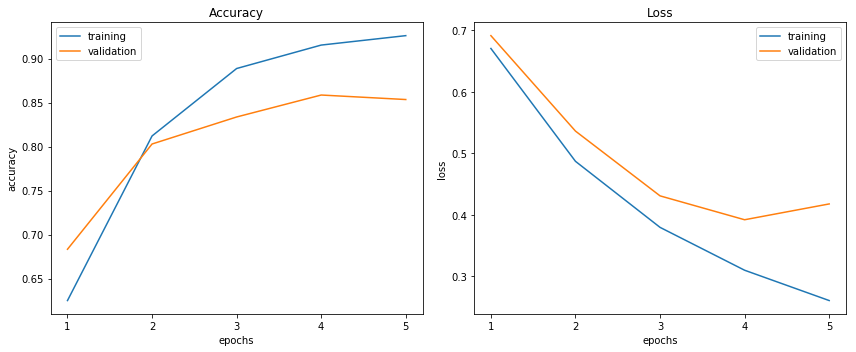

In [99]:
# Plot the training and validation accuracy

fig, axs = plt.subplots(1, 2, figsize=[12, 5])
epochs = list(range(1, 6))

axs[0].plot(epochs, history.history['accuracy'], label='training')
axs[0].plot(epochs, history.history['val_accuracy'], label='validation')

axs[1].plot(epochs, history.history['loss'], label='training')
axs[1].plot(epochs, history.history['val_loss'], label='validation')


axs[0].set(xlabel='epochs', ylabel='accuracy', xticks=[1, 2, 3, 4, 5])
axs[1].set(xlabel='epochs', ylabel='loss', xticks=[1, 2, 3, 4, 5])
axs[0].set_title('Accuracy')
axs[1].set_title('Loss')
axs[0].legend()
axs[1].legend()

fig.tight_layout()